# 🏠 Rental Price Prediction Using Machine Learning

## Project Title

Rental Price Prediction Using Machine Learning

---

## Business Problem

Finding the right rental price for a property is often difficult for both property owners and tenants. Many owners set prices based on personal judgment or local market trends, which can lead to overpricing or underpricing. As a result, properties may stay vacant for longer periods or generate lower rental income.

A machine learning solution can help estimate rental prices more accurately by analyzing property characteristics such as location, size, number of bedrooms, furnishing status, and nearby amenities.

---

## Objective

The objective of this project is to build a regression model that predicts the monthly rental price of a property using its features. The model should provide accurate rental price predictions and help property owners make informed pricing decisions.

---

## Dataset Description

This dataset contains rental property listings collected from different cities across India. It includes important information about each property, such as:

- City
- Locality
- Property Type
- Number of Bedrooms (BHK)
- Property Size (Square Feet)
- Number of Bathrooms
- Furnishing Status
- Property Age
- Distance from City Center
- Security Deposit
- Monthly Rental Price (Target Variable)

The dataset contains approximately **50,000 rental property records** with **25 features**, making it suitable for building and evaluating machine learning regression models.

---

## Success Criteria

The project will be considered successful if the machine learning model:

- Predicts monthly rental prices with good accuracy.
- Achieves a high R² Score.
- Produces low MAE and RMSE values.
- Generalizes well on unseen test data.
- Can be used as a reliable rental price estimation system for real-world properties.

## 1.Data Understanding

#### 1.1 Import Necessary Libraries

In [0]:

pip install XGBoost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 182.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 MB 166.0 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

import scipy.stats as stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

import joblib



#### 1.2 Import Dataset

In [0]:
Rental_Data=spark.table("workspace.default.india_rental_dataset")
Rental_Data.toPandas().head()

,listing_id,city,locality,city_tier,property_type,bhk,size_sqft,bathrooms,balconies,furnishing,floor,total_floors,age_of_property_years,has_parking,has_lift,has_security,has_gym,has_pool,has_power_backup,near_metro,distance_to_city_center_km,tenant_preference,available_from,security_deposit_inr,monthly_rent_inr
0,RNT100000,Bangalore,Marathahalli,1,PG/Co-living,2,244,2,0.0,Fully Furnished,2,25,21.0,0,1,1,0,0,0,1,8.7,Bachelors,2025-04-19,16400,8200
1,RNT100001,Hyderabad,Gachibowli,2,Apartment,2,866,1,1.0,Semi-Furnished,4,4,18.0,1,0,0,1,0,0,0,3.1,Family,2025-03-03,60900,20300
2,RNT100002,Pune,Hinjewadi,2,Apartment,3,1449,3,1.0,Semi-Furnished,30,30,17.0,1,1,1,1,0,0,0,4.1,Bachelors,2024-02-22,87200,43600
3,RNT100003,Hyderabad,Miyapur,2,PG/Co-living,1,252,1,0.0,Semi-Furnished,2,2,10.0,0,1,1,0,0,1,1,9.4,Any,2024-02-02,27000,4500
4,RNT100004,Mumbai,Thane,1,Apartment,2,1048,1,1.0,Unfurnished,2,15,0.0,1,1,0,0,0,0,0,2.8,Any,2024-04-05,257700,85900


In [0]:
Rental_Data=Rental_Data.toPandas()

#### 1.3 Data Clarification

In [0]:
Rental_Data.shape

(50000, 25)

In [0]:

Rental_Data.describe()


,city_tier,bhk,size_sqft,bathrooms,balconies,floor,total_floors,age_of_property_years,has_parking,has_lift,has_security,has_gym,has_pool,has_power_backup,near_metro,distance_to_city_center_km,security_deposit_inr,monthly_rent_inr
count,50000.000000,50000.000000,50000.00000,50000.000000,49500.000000,50000.000000,50000.00000,49250.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,5.000000e+04,50000.000000
mean,1.665940,2.226240,1078.26590,1.940300,1.350323,7.057380,14.18728,14.458518,0.651180,0.74158,0.703080,0.201240,0.081980,0.600280,0.39516,9.006434,1.654855e+05,42048.990000
std,0.683896,1.011373,565.15635,0.970111,0.850915,7.608535,10.81183,8.619190,0.476602,0.43777,0.456906,0.400931,0.274337,0.489846,0.48889,7.858437,2.001459e+05,37382.265925
min,1.000000,1.000000,220.00000,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,8.000000e+03,4000.000000
25%,1.000000,1.000000,592.00000,1.000000,1.000000,1.000000,2.00000,7.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,3.300000,5.250000e+04,17500.000000
50%,2.000000,2.000000,1018.00000,2.000000,1.000000,4.000000,13.00000,14.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,0.00000,6.600000,1.011000e+05,31200.000000
75%,2.000000,3.000000,1395.00000,3.000000,2.000000,11.000000,24.00000,22.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,1.00000,12.200000,1.998000e+05,54200.000000
max,3.000000,5.000000,3783.00000,5.000000,3.000000,34.000000,34.00000,29.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.00000,45.000000,4.230000e+06,474700.000000


In [0]:
Rental_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   listing_id                  50000 non-null  object 
 1   city                        50000 non-null  object 
 2   locality                    50000 non-null  object 
 3   city_tier                   50000 non-null  int64  
 4   property_type               50000 non-null  object 
 5   bhk                         50000 non-null  int64  
 6   size_sqft                   50000 non-null  int64  
 7   bathrooms                   50000 non-null  int64  
 8   balconies                   49500 non-null  float64
 9   furnishing                  50000 non-null  object 
 10  floor                       50000 non-null  int64  
 11  total_floors                50000 non-null  int64  
 12  age_of_property_years       49250 non-null  float64
 13  has_parking                 500

#### Summary Statistics

In [0]:
Rental_Data.describe(include='object')

,listing_id,city,locality,property_type,furnishing,tenant_preference,available_from
count,50000,50000,50000,50000,50000,50000,50000
unique,50000,12,67,5,3,4,545
top,RNT100000,Mumbai,Lajpat Nagar,Apartment,Unfurnished,Family,2024-07-12
freq,1,7945,1110,31077,20068,17501,124


## 2 Data Cleaning

In [0]:
Rental_Data.isnull().sum()


listing_id                      0
city                            0
locality                        0
city_tier                       0
property_type                   0
bhk                             0
size_sqft                       0
bathrooms                       0
balconies                     500
furnishing                      0
floor                           0
total_floors                    0
age_of_property_years         750
has_parking                     0
has_lift                        0
has_security                    0
has_gym                         0
has_pool                        0
has_power_backup                0
near_metro                      0
distance_to_city_center_km      0
tenant_preference               0
available_from                  0
security_deposit_inr            0
monthly_rent_inr                0
dtype: int64

##### Balconies contains nearly 500 Nan Values . Let's assign Median  to these NaN Values

In [0]:
Rental_Data["balconies"].value_counts(dropna=False)

balconies
1.0    22453
2.0    14760
0.0     7331
3.0     4956
NaN      500
Name: count, dtype: int64

In [0]:
Rental_Data.groupby("property_type")["balconies"].apply(lambda x: x.isnull().sum())

property_type
Apartment            317
Independent House     73
PG/Co-living          36
Studio                47
Villa                 27
Name: balconies, dtype: int64

In [0]:
Rental_Data["balconies"]=Rental_Data["balconies"].fillna(Rental_Data["balconies"].median())

##### There are 750 NaN values in Age of the Property . Let's assign the median values  based on the property type.

In [0]:
Rental_Data["age_of_property_years"] = Rental_Data.groupby("property_type")["age_of_property_years"].transform(lambda x: x.fillna(x.median()))

####  Now , check the data is clean after the cleaning process

In [0]:
Rental_Data.isnull().sum()

listing_id                    0
city                          0
locality                      0
city_tier                     0
property_type                 0
bhk                           0
size_sqft                     0
bathrooms                     0
balconies                     0
furnishing                    0
floor                         0
total_floors                  0
age_of_property_years         0
has_parking                   0
has_lift                      0
has_security                  0
has_gym                       0
has_pool                      0
has_power_backup              0
near_metro                    0
distance_to_city_center_km    0
tenant_preference             0
available_from                0
security_deposit_inr          0
monthly_rent_inr              0
dtype: int64

##### There is No null values lets check the whether the dataset contains Duplicated Records

In [0]:
Rental_Data.duplicated().sum()

np.int64(0)

#### Now,The Dataset is cleaned and ready to Processing

## 3.Exploratory Data Analysis


#### 3.1 Highest Average rent by city


In [0]:
Rental_Data.groupby("city")["monthly_rent_inr"].mean().sort_values(ascending=False)

city
Mumbai        84849.427313
Delhi         54016.056639
Bangalore     44405.268135
Chennai       32832.196689
Pune          31594.782416
Hyderabad     29528.533974
Chandigarh    28378.897243
Kolkata       24253.112507
Ahmedabad     19808.547718
Kochi         17283.240787
Jaipur        15460.191847
Lucknow       14109.443099
Name: monthly_rent_inr, dtype: float64

#### 3.2 Lowest Average rent by city

In [0]:
Rental_Data.groupby("city")["monthly_rent_inr"].mean().sort_values()

city
Lucknow       14109.443099
Jaipur        15460.191847
Kochi         17283.240787
Ahmedabad     19808.547718
Kolkata       24253.112507
Chandigarh    28378.897243
Hyderabad     29528.533974
Pune          31594.782416
Chennai       32832.196689
Bangalore     44405.268135
Delhi         54016.056639
Mumbai        84849.427313
Name: monthly_rent_inr, dtype: float64

#### 3.3 Average Rent by Property Type

In [0]:
Rental_Data.groupby("property_type")["monthly_rent_inr"].mean().sort_values(ascending=False)

property_type
Villa                113496.120108
Independent House     48117.377399
Apartment             40343.109052
Studio                18195.921112
PG/Co-living           8152.896890
Name: monthly_rent_inr, dtype: float64

#### 3.4 Average Rent by BHK

In [0]:
Rental_Data.groupby("bhk")["monthly_rent_inr"].mean().sort_values()

bhk
1     18466.524981
2     37501.434199
3     56963.218475
4     75088.491752
5    109423.630137
Name: monthly_rent_inr, dtype: float64

#### 3.5 Average Rent by Furnishing Status

In [0]:
Rental_Data.groupby("furnishing")["monthly_rent_inr"].mean().sort_values(ascending=False)

furnishing
Fully Furnished    51854.285714
Semi-Furnished     42979.775733
Unfurnished        36218.576839
Name: monthly_rent_inr, dtype: float64

#### 3.6 Average Rent by Property Age

In [0]:
Rental_Data.groupby("age_of_property_years")["monthly_rent_inr"].mean().sort_values()

age_of_property_years
29.0    37721.542384
26.0    38400.751880
25.0    39166.522009
24.0    39259.481161
23.0    39427.674568
28.0    39529.694323
21.0    39825.202312
15.0    39981.782066
27.0    40024.057451
22.0    40025.105358
19.0    40103.814064
17.0    40633.460317
16.0    40886.603438
18.0    40902.948113
20.0    41041.625917
12.0    42706.474820
13.0    42792.625899
14.0    42857.408207
8.0     42870.874349
7.0     42997.924298
11.0    43461.076345
5.0     43703.489771
3.0     44422.916667
9.0     44438.504326
4.0     45051.267780
10.0    45137.696970
6.0     45436.564417
0.0     45698.418491
1.0     46133.457019
2.0     46378.842676
Name: monthly_rent_inr, dtype: float64

#### 3.7 Average Rent by Bathrooms

In [0]:
Rental_Data.groupby("bathrooms")["monthly_rent_inr"].mean().sort_values()

bathrooms
1     24345.737216
2     44744.144909
3     60136.257424
4     78362.780683
5    108474.857143
Name: monthly_rent_inr, dtype: float64

#### 3.8 Average Rent by Balconies

In [0]:
Rental_Data.groupby("balconies")["monthly_rent_inr"].mean().sort_values()

balconies
0.0    41250.525167
2.0    41965.304878
3.0    42047.699758
1.0    42358.105694
Name: monthly_rent_inr, dtype: float64

#### 3.9 Distance from City Center vs Average Rent

In [0]:
Rental_Data.groupby("distance_to_city_center_km")["monthly_rent_inr"].mean().sort_values()

distance_to_city_center_km
43.2     6866.666667
44.6     8500.000000
43.3    11733.333333
44.8    11950.000000
35.6    12300.000000
            ...     
44.3    50900.000000
44.4    52250.000000
36.6    54490.000000
44.2    56050.000000
40.1    57375.000000
Name: monthly_rent_inr, Length: 441, dtype: float64

#### 3.10 Top 10 Expensive Localities

In [0]:
Rental_Data.groupby("locality")["monthly_rent_inr"].mean().sort_values(ascending=False).head(10)

locality
Chembur        86222.600619
Bandra         86005.882353
Malad          85716.065911
Goregaon       84930.872483
Andheri        84616.082474
Borivali       84547.991761
Powai          84513.748764
Thane          82370.019531
Rohini         56693.345488
Vasant Kunj    54526.636364
Name: monthly_rent_inr, dtype: float64

#### 3.11 Top 10 Affordable Localities

In [0]:
Rental_Data.groupby("locality")["monthly_rent_inr"].mean().sort_values().head(10)

locality
Hazratganj        13815.667311
Indira Nagar      13937.475728
Gomti Nagar       14324.950884
Aliganj           14358.969466
Malviya Nagar     15021.338156
Vaishali Nagar    15453.832117
Mansarovar        15534.791252
C-Scheme          15893.970894
Vyttila           16715.338645
Kaloor            17031.732777
Name: monthly_rent_inr, dtype: float64

#### 3.12 Property Size vs Rent

In [0]:
Rental_Data[["size_sqft","monthly_rent_inr"]].corr()

,size_sqft,monthly_rent_inr
size_sqft,1.000000,0.654436
monthly_rent_inr,0.654436,1.000000


#### 3.13 Security Deposit vs Rent

In [0]:
Rental_Data[["security_deposit_inr","monthly_rent_inr"]].corr()

,security_deposit_inr,monthly_rent_inr
security_deposit_inr,1.000000,0.724646
monthly_rent_inr,0.724646,1.000000


#### 3.14 Correlation Heatmap

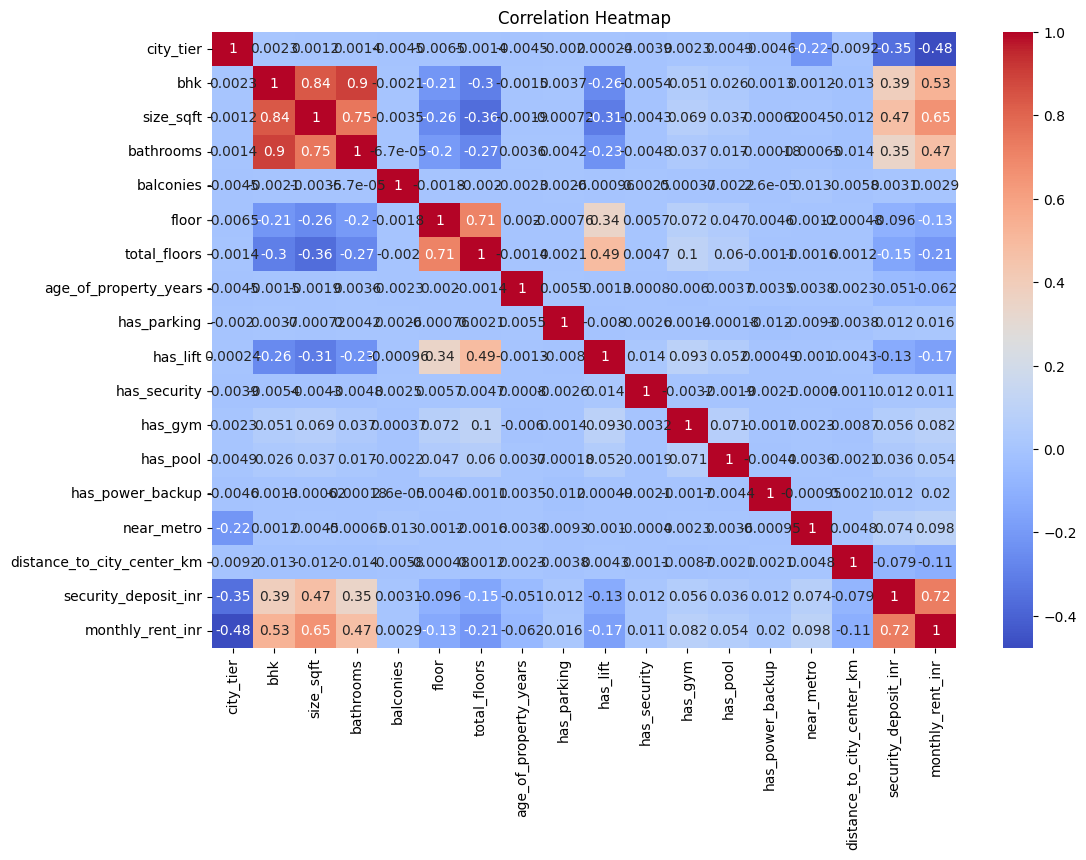

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(Rental_Data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 4.Feature Engineering 

#### 4.1 Rent Per Sqft

In [0]:
Rental_Data["Rent_per_Sqft"]=Rental_Data["monthly_rent_inr"] / Rental_Data["size_sqft"]
Rental_Data

,listing_id,city,locality,city_tier,property_type,bhk,size_sqft,bathrooms,balconies,furnishing,floor,total_floors,age_of_property_years,has_parking,has_lift,has_security,has_gym,has_pool,has_power_backup,near_metro,distance_to_city_center_km,tenant_preference,available_from,security_deposit_inr,monthly_rent_inr,Rent_per_Sqft
0,RNT100000,Bangalore,Marathahalli,1,PG/Co-living,2,244,2,0.0,Fully Furnished,2,25,21.0,0,1,1,0,0,0,1,8.7,Bachelors,2025-04-19,16400,8200,33.606557
1,RNT100001,Hyderabad,Gachibowli,2,Apartment,2,866,1,1.0,Semi-Furnished,4,4,18.0,1,0,0,1,0,0,0,3.1,Family,2025-03-03,60900,20300,23.441109
2,RNT100002,Pune,Hinjewadi,2,Apartment,3,1449,3,1.0,Semi-Furnished,30,30,17.0,1,1,1,1,0,0,0,4.1,Bachelors,2024-02-22,87200,43600,30.089717
3,RNT100003,Hyderabad,Miyapur,2,PG/Co-living,1,252,1,0.0,Semi-Furnished,2,2,10.0,0,1,1,0,0,1,1,9.4,Any,2024-02-02,27000,4500,17.857143
4,RNT100004,Mumbai,Thane,1,Apartment,2,1048,1,1.0,Unfurnished,2,15,0.0,1,1,0,0,0,0,0,2.8,Any,2024-04-05,257700,85900,81.965649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,RNT149995,Chennai,Velachery,2,Apartment,3,1293,3,2.0,Semi-Furnished,0,11,10.0,0,0,0,0,0,0,0,8.4,Family,2024-02-01,105000,35000,27.068832
49996,RNT149996,Mumbai,Bandra,1,Apartment,3,1373,3,3.0,Semi-Furnished,2,29,13.0,1,1,1,0,0,0,0,7.2,Bachelors,2025-03-12,693600,115600,84.195193
49997,RNT149997,Mumbai,Malad,1,Independent House,3,1544,2,2.0,Unfurnished,0,2,17.0,1,1,1,0,0,0,0,16.4,Any,2024-06-01,259500,86500,56.023316
49998,RNT149998,Bangalore,JP Nagar,1,Independent House,2,1558,1,1.0,Fully Furnished,1,2,28.0,0,0,1,0,0,0,0,12.6,Bachelors,2024-06-20,172800,57600,36.970475


#### 4.2 Total Amenities

In [0]:
Rental_Data["total_amenities"] = (
    Rental_Data["has_parking"]
    + Rental_Data["has_lift"]
    + Rental_Data["has_security"]
    + Rental_Data["has_gym"]
    + Rental_Data["has_pool"]
    + Rental_Data["has_power_backup"]
    + Rental_Data["near_metro"]
)
Rental_Data

,listing_id,city,locality,city_tier,property_type,bhk,size_sqft,bathrooms,balconies,furnishing,floor,total_floors,age_of_property_years,has_parking,has_lift,has_security,has_gym,has_pool,has_power_backup,near_metro,distance_to_city_center_km,tenant_preference,available_from,security_deposit_inr,monthly_rent_inr,Rent_per_Sqft,total_amenities
0,RNT100000,Bangalore,Marathahalli,1,PG/Co-living,2,244,2,0.0,Fully Furnished,2,25,21.0,0,1,1,0,0,0,1,8.7,Bachelors,2025-04-19,16400,8200,33.606557,3
1,RNT100001,Hyderabad,Gachibowli,2,Apartment,2,866,1,1.0,Semi-Furnished,4,4,18.0,1,0,0,1,0,0,0,3.1,Family,2025-03-03,60900,20300,23.441109,2
2,RNT100002,Pune,Hinjewadi,2,Apartment,3,1449,3,1.0,Semi-Furnished,30,30,17.0,1,1,1,1,0,0,0,4.1,Bachelors,2024-02-22,87200,43600,30.089717,4
3,RNT100003,Hyderabad,Miyapur,2,PG/Co-living,1,252,1,0.0,Semi-Furnished,2,2,10.0,0,1,1,0,0,1,1,9.4,Any,2024-02-02,27000,4500,17.857143,4
4,RNT100004,Mumbai,Thane,1,Apartment,2,1048,1,1.0,Unfurnished,2,15,0.0,1,1,0,0,0,0,0,2.8,Any,2024-04-05,257700,85900,81.965649,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,RNT149995,Chennai,Velachery,2,Apartment,3,1293,3,2.0,Semi-Furnished,0,11,10.0,0,0,0,0,0,0,0,8.4,Family,2024-02-01,105000,35000,27.068832,0
49996,RNT149996,Mumbai,Bandra,1,Apartment,3,1373,3,3.0,Semi-Furnished,2,29,13.0,1,1,1,0,0,0,0,7.2,Bachelors,2025-03-12,693600,115600,84.195193,3
49997,RNT149997,Mumbai,Malad,1,Independent House,3,1544,2,2.0,Unfurnished,0,2,17.0,1,1,1,0,0,0,0,16.4,Any,2024-06-01,259500,86500,56.023316,3
49998,RNT149998,Bangalore,JP Nagar,1,Independent House,2,1558,1,1.0,Fully Furnished,1,2,28.0,0,0,1,0,0,0,0,12.6,Bachelors,2024-06-20,172800,57600,36.970475,1


#### 4.3 Deposit to Rent ratio

In [0]:
Rental_Data["deposit_rent_ratio"] =  Rental_Data["security_deposit_inr"] / Rental_Data["monthly_rent_inr"]

Rental_Data

,listing_id,city,locality,city_tier,property_type,bhk,size_sqft,bathrooms,balconies,furnishing,floor,total_floors,age_of_property_years,has_parking,has_lift,has_security,has_gym,has_pool,has_power_backup,near_metro,distance_to_city_center_km,tenant_preference,available_from,security_deposit_inr,monthly_rent_inr,Rent_per_Sqft,total_amenities,deposit_rent_ratio
0,RNT100000,Bangalore,Marathahalli,1,PG/Co-living,2,244,2,0.0,Fully Furnished,2,25,21.0,0,1,1,0,0,0,1,8.7,Bachelors,2025-04-19,16400,8200,33.606557,3,2.0
1,RNT100001,Hyderabad,Gachibowli,2,Apartment,2,866,1,1.0,Semi-Furnished,4,4,18.0,1,0,0,1,0,0,0,3.1,Family,2025-03-03,60900,20300,23.441109,2,3.0
2,RNT100002,Pune,Hinjewadi,2,Apartment,3,1449,3,1.0,Semi-Furnished,30,30,17.0,1,1,1,1,0,0,0,4.1,Bachelors,2024-02-22,87200,43600,30.089717,4,2.0
3,RNT100003,Hyderabad,Miyapur,2,PG/Co-living,1,252,1,0.0,Semi-Furnished,2,2,10.0,0,1,1,0,0,1,1,9.4,Any,2024-02-02,27000,4500,17.857143,4,6.0
4,RNT100004,Mumbai,Thane,1,Apartment,2,1048,1,1.0,Unfurnished,2,15,0.0,1,1,0,0,0,0,0,2.8,Any,2024-04-05,257700,85900,81.965649,2,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,RNT149995,Chennai,Velachery,2,Apartment,3,1293,3,2.0,Semi-Furnished,0,11,10.0,0,0,0,0,0,0,0,8.4,Family,2024-02-01,105000,35000,27.068832,0,3.0
49996,RNT149996,Mumbai,Bandra,1,Apartment,3,1373,3,3.0,Semi-Furnished,2,29,13.0,1,1,1,0,0,0,0,7.2,Bachelors,2025-03-12,693600,115600,84.195193,3,6.0
49997,RNT149997,Mumbai,Malad,1,Independent House,3,1544,2,2.0,Unfurnished,0,2,17.0,1,1,1,0,0,0,0,16.4,Any,2024-06-01,259500,86500,56.023316,3,3.0
49998,RNT149998,Bangalore,JP Nagar,1,Independent House,2,1558,1,1.0,Fully Furnished,1,2,28.0,0,0,1,0,0,0,0,12.6,Bachelors,2024-06-20,172800,57600,36.970475,1,3.0


## 5. Let's check for the Assumption

#### TEST 1: Linearity Test

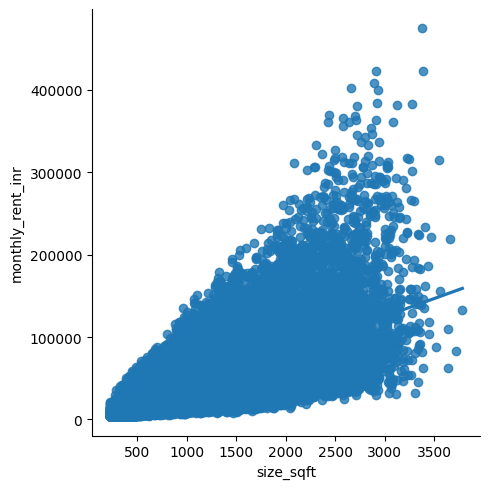

In [0]:
sns.lmplot(x="size_sqft", y="monthly_rent_inr", data=Rental_Data)

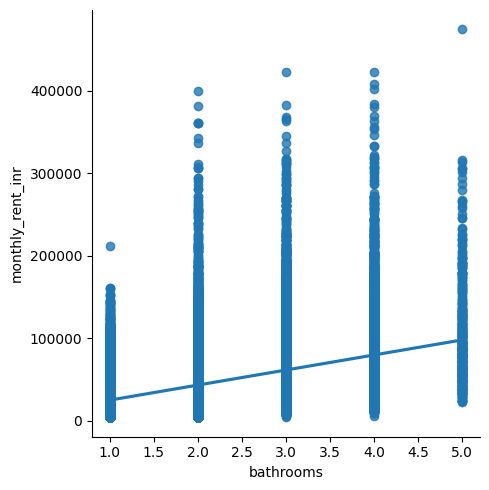

In [0]:
sns.lmplot(x="bathrooms", y="monthly_rent_inr", data=Rental_Data)

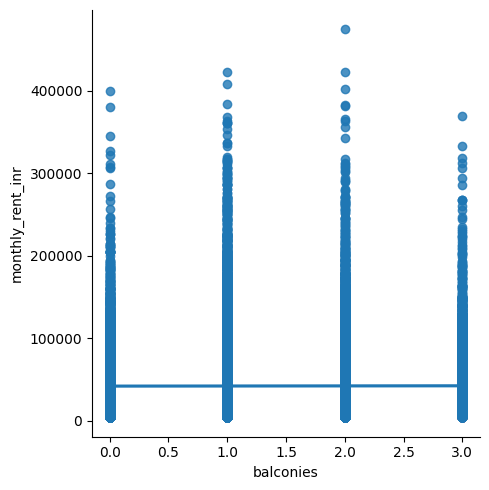

In [0]:
sns.lmplot(x="balconies", y="monthly_rent_inr", data=Rental_Data)

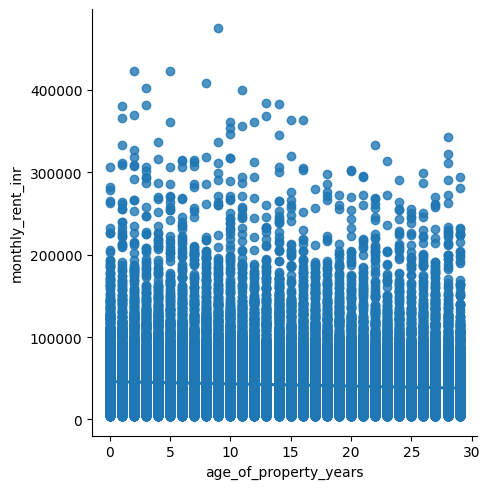

In [0]:
sns.lmplot(x="age_of_property_years", y="monthly_rent_inr", data=Rental_Data)

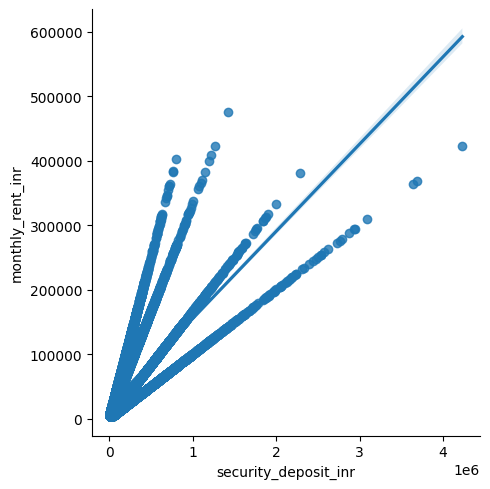

In [0]:
sns.lmplot(x="security_deposit_inr", y="monthly_rent_inr", data=Rental_Data)

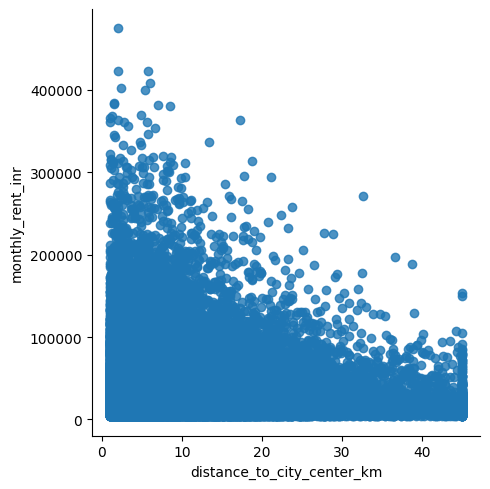

In [0]:
sns.lmplot(x="distance_to_city_center_km", y="monthly_rent_inr", data=Rental_Data)

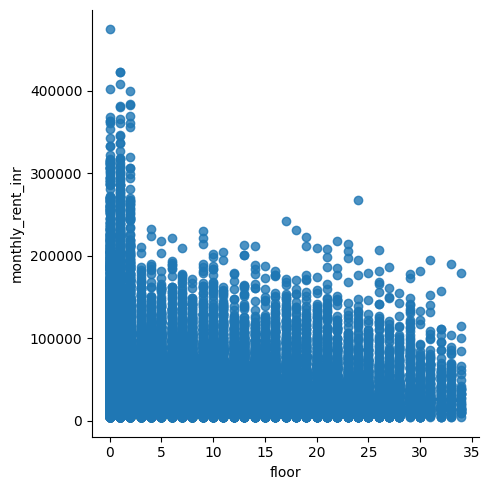

In [0]:
sns.lmplot(x="floor", y="monthly_rent_inr", data=Rental_Data)

#### Overall Linearity test is passed

#### TEST 2:Multicollinearity Test

In [0]:
cols = [ "size_sqft","bhk","bathrooms","balconies","floor","total_floors","age_of_property_years","has_parking","has_lift","has_security", "has_gym", "has_pool", "has_power_backup", "near_metro", "distance_to_city_center_km", "security_deposit_inr"]


In [0]:
X = Rental_Data[cols]

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Feature,VIF
0,size_sqft,17.825859
1,bhk,43.527431
2,bathrooms,25.575109
3,balconies,3.186718
4,floor,3.719801
5,total_floors,6.357418
6,age_of_property_years,3.457125
7,has_parking,2.658795
8,has_lift,4.729182
9,has_security,3.073890


## 6.Data Processing

#### 6.1 Encode the some categorical columns for Model traning

In [0]:
categorical_cols = ["city","property_type","furnishing","tenant_preference"]


Rental_Data = pd.get_dummies(Rental_Data,columns=categorical_cols,drop_first=True,dtype=int)



#### 6.2  Split the Input and Output for Model training and testing

In [0]:
# Features X and Target Y

X = Rental_Data.drop("monthly_rent_inr", axis=1)
y = Rental_Data["monthly_rent_inr"]


In [0]:
X = X.drop(["listing_id", "locality", "available_from","Rent_per_Sqft","deposit_rent_ratio","security_deposit_inr"], axis=1)

In [0]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [0]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (40000, 37)
X_test : (10000, 37)
y_train: (40000,)
y_test : (10000,)


## 7.Model Building

In [0]:
Linear_model = LinearRegression()


## 8.Model Training

In [0]:
Linear_model.fit(X_train,y_train)


LinearRegression()

## 9.Model Prediction

In [0]:
y_predict=Linear_model.predict(X_test)

#### Lets Perform the Homoscedasticity and Residuals Normality test for Assumption

#### Homoscedasticity test:

In [0]:
Residuals = y_test-y_predict

Text(0, 0.5, 'Residual')

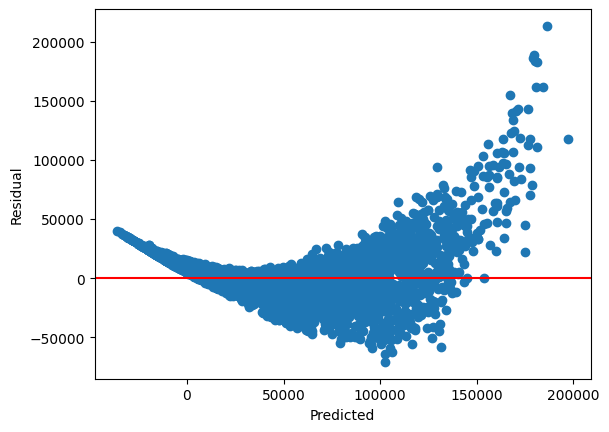

In [0]:
plt.scatter(y_predict,Residuals)
plt.axhline(y=0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")

#### Residual Normality test:

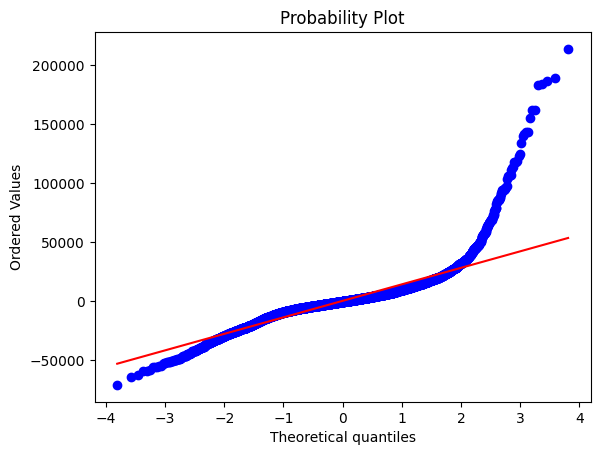

In [0]:
stats.probplot(x=Residuals, dist="norm", plot=plt)
plt.show()


#### The Assumption of Homoscedasticity and Residuals Normality test Failed

#### Model Evaluation for Linear Regression

In [0]:
y_pred = Linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 9380.143577926847
MSE : 242645572.9466949
RMSE : 15577.084866774492
R2 Score : 0.8324639401842231


## Let's Perform the Ridge Regression because the Dataset contains with Multicollinearity with important input features.

#### Model Building:

In [0]:
Ridge_Model=Ridge()

#### Model Training:

In [0]:
Ridge_Model.fit(X_train,y_train)


Ridge()

#### Model Prediction:

In [0]:
y_ridge_predict=Ridge_Model.predict(X_test)


#### Lets perform the Homoscedasticity and Resdiduals Normality test for Ridge Regression

#### Homoscedasticity :

In [0]:
Residuals_Ridge=y_test-y_ridge_predict

Text(0, 0.5, 'Residuals')

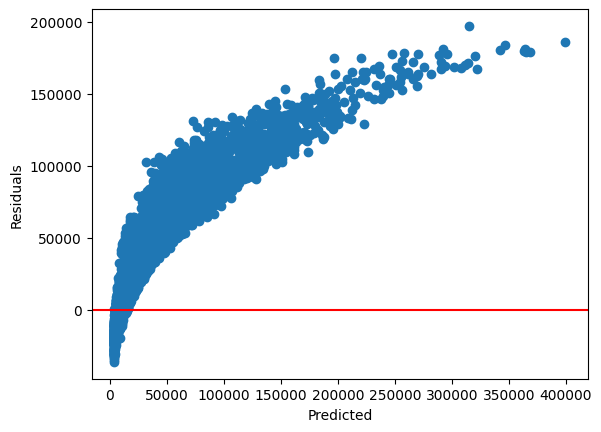

In [0]:
plt.scatter(y_test,y_ridge_predict)
plt.axhline(y=0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")

#### Residuals Normality:

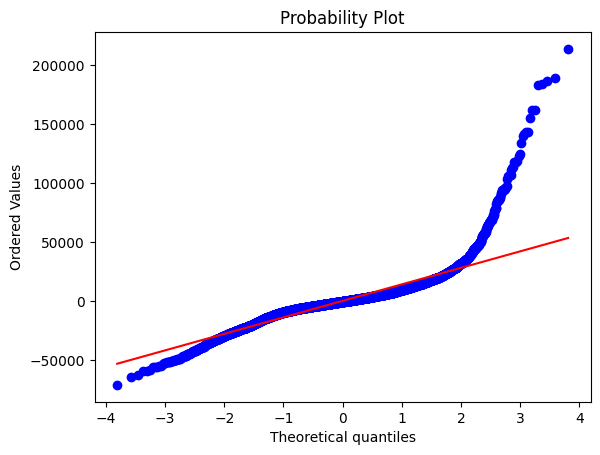

In [0]:
stats.probplot(Residuals_Ridge, dist="norm", plot=plt)
plt.show()


#### Model Evaluation for Ridge Regression

In [0]:
y_ridge_pred = Ridge_Model.predict(X_test)

mae = mean_absolute_error(y_test, y_ridge_pred)
mse = mean_squared_error(y_test, y_ridge_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_ridge_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 9379.823862193041
MSE : 242648831.05613178
RMSE : 15577.189446627777
R2 Score : 0.8324616906034421


### I checked the Linear Regression assumptions. Residual normality and homoscedasticity were not fully satisfied. However, the model still achieved an R² score of about 0.91, so it provides good predictive performance. Since the assumptions were violated, I treated the model as useful for prediction but interpreted the coefficients with caution, and I would consider feature engineering or tree-based models for further improvement.

## Random Forest:


#### Model Building

In [0]:
Random_Model = RandomForestRegressor( n_estimators=100, random_state=42)



#### Model Training

In [0]:
Random_Model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

#### Model Prediction

In [0]:
y_random_pred = Random_Model.predict(X_test)

#### Model Evaluation

In [0]:
mae = mean_absolute_error(y_test, y_random_pred)
mse = mean_squared_error(y_test, y_random_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_random_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 3427.7174
MSE : 34175768.1878
RMSE : 5846.004463546021
R2 Score : 0.976403140292944


## Hyperparameter Tuning for Random Forest

#### Parameter Grid

In [0]:
param_dist = {'n_estimators': [100, 200, 300, 500],'max_depth': [10, 20, 30, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2']}


#### Create Model

In [0]:
rf = RandomForestRegressor(random_state=42)

#### RandomizedSearchCV

In [0]:
random_search = RandomizedSearchCV(estimator=rf,param_distributions=param_dist,n_iter=20,cv=5,scoring='r2',random_state=42,n_jobs=-1)


#### Model Train

In [0]:
random_search.fit(X_train, y_train)

/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2')

#### Best Parameter

In [0]:
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV Score: 0.959176952742317


#### Model Prediction

In [0]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

#### Hyperparameter Model Evaluation

In [0]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 4328.287525000001
MSE : 54527816.15392014
RMSE : 7384.295237456323
R2 Score : 0.9623509493379723


#### Let's perfrom Boosting Algorithm

## XGBoost

#### Model Building

In [0]:
gb_model = GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)


gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

#### Model Training

In [0]:
gb_model.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

#### Model Prediction

In [0]:
y_gb_pred=gb_model.predict(X_test)


#### Model Evaluation

In [0]:
mae = mean_absolute_error(y_test, y_gb_pred)
mse = mean_squared_error(y_test, y_gb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_gb_pred)

print("Gradient Boosting Evaluation")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

Gradient Boosting Evaluation
MAE : 4302.93986270865
MSE : 50396448.04649751
RMSE : 7099.045572927216
R2 Score : 0.9652034766928325


## Hyperparameter Tuning for XGBoost

#### XGBoost Model

In [0]:
xgb = XGBRegressor(objective='reg:squarederror',random_state=42)


#### Parameter Grid

In [0]:
param_dist = {'n_estimators': [100, 200, 300],'max_depth': [3, 5, 7],'learning_rate': [0.01, 0.05, 0.1],'subsample': [0.8, 1.0],'colsample_bytree': [0.8, 1.0]}


#### RandomizedSearchCV

In [0]:
random_search_xgb = RandomizedSearchCV( estimator=xgb,param_distributions=param_dist,n_iter=20, cv=5, scoring='r2', random_state=42, n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2')

#### Best parameters

In [0]:
print("Best Parameters:", random_search_xgb.best_params_)
print("Best CV Score:", random_search_xgb.best_score_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV Score: 0.981488049030304


#### Best XGBoost model prediction

In [0]:
best_xgb = random_search_xgb.best_estimator_

y_xgb_pred = best_xgb.predict(X_test)

#### Hyperparameter Model Evaluation for XGboost

In [0]:
mae = mean_absolute_error(y_test, y_xgb_pred)
mse = mean_squared_error(y_test, y_xgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_xgb_pred)

print("XGBoost Tuned Evaluation")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

XGBoost Tuned Evaluation
MAE : 3060.468505859375
MSE : 26735182.0
RMSE : 5170.607507827296
R2 Score : 0.9815405607223511


## 10. Model Selection

In [0]:
best_xgb = random_search_xgb.best_estimator_

## 11. Model Saving

In [0]:
joblib.dump(best_xgb, "Rental_prediction.joblib")

print("Model Saved Successfully")

Model Saved Successfully
